In [1]:
from add_methods_utils import add_methods_to_lightweight_file
from saving_experiments import load_samples, save_samples
from main_code import run_diffusion_experiment, add_gillespie_reverse
from plotting_functions import plot_method_comparison
import numpy as np
import time

In [2]:


# ===== Parameters =====
N = 8
L = 2
r = 10
beta = 5.0
T = 3.5
n_mc = 10_000

w = np.ones(r) / r
mu = np.random.dirichlet([1]*L, size=(r, N))

u = np.linspace(0, 1, 31)
checkpoint_times = T * (u ** 12)

print("=" * 70)
print("DPC CORRECTOR TEST EXPERIMENT")
print("=" * 70)
print(f"\nParameters:")
print(f"  N={N}, L={L}, r={r}")
print(f"  beta={beta}, T={T}, n_mc={n_mc:,}")

# ===== Run Forward + Gillespie =====
print("\nRunning forward + Gillespie...")
start = time.time()
samples = run_diffusion_experiment(w, mu, beta, T, n_mc, checkpoint_times)
add_gillespie_reverse(samples, w, mu, beta, T)
print(f"  Done in {time.time() - start:.1f} seconds")

# ===== Save Lightweight =====
experiment_metadata = {
    'N': N, 'L': L, 'r': r,
    'beta': beta, 'T': T, 'n_mc': n_mc,
    'w': w.tolist(),
    'mu': mu.tolist(),
    'checkpoint_formula': 'T * (u ** 12) where u = linspace(0, 1, 31)',
    'n_checkpoints': len(checkpoint_times),
    'methods': samples.list_methods(),
    'date': '2026-05-27',
    'notes': 'DPC corrector test experiment N=8, L=2, n_mc=10k'
}

filename = 'gillespie_nmc_10k_DPC'
print(f"\nSaving lightweight file: {filename}.pkl")
save_samples(samples, filename + '.pkl', 
             metadata=experiment_metadata,
             lightweight=True, L=L)

# ===== Add Tau-leap Baseline =====
print("\nAdding tau-leap baseline (tau=0.4)...")
methods_to_add = [
    {
        'type': 'tau_leap',
        'tau': 0.4,
        'corrector': False
    }
]
add_methods_to_lightweight_file(filename + '.pkl', methods_to_add)


DPC CORRECTOR TEST EXPERIMENT

Parameters:
  N=8, L=2, r=10
  beta=5.0, T=3.5, n_mc=10,000

Running forward + Gillespie...
Running forward process...
Running Gillespie reverse process...
  Gillespie particle 0/10000
  Done in 8.1 seconds

Saving lightweight file: gillespie_nmc_10k_DPC.pkl
Computing empirical joint PMFs for lightweight save...
Samples saved (LIGHTWEIGHT - Joint PMFs) to: gillespie_nmc_10k_DPC.pkl
  - Forward PMFs: 31 checkpoints
  - Reverse PMFs: 1 methods
  - File size: 1.28 MB
  - n_mc: 10000, N: 8
  - User metadata: ['N', 'L', 'r', 'beta', 'T', 'n_mc', 'w', 'mu', 'checkpoint_formula', 'n_checkpoints', 'methods', 'date', 'notes']

Adding tau-leap baseline (tau=0.4)...
ADDING METHODS TO LIGHTWEIGHT SAVE

Loading: gillespie_nmc_10k_DPC.pkl
Samples loaded (LIGHTWEIGHT - PMFs) from: gillespie_nmc_10k_DPC.pkl
  - Forward PMFs: 31 checkpoints
  - Reverse PMFs: 1 methods
  - n_mc: 10000, N: 8, L: 2
  - User metadata: ['N', 'L', 'r', 'beta', 'T', 'n_mc', 'w', 'mu', 'checkpoin

{'methods_added': ['tau_leap_0.4'],
 'total_methods': 2,
 'file_size_mb': 1.4364433288574219,
 'existing_methods': ['gillespie', 'tau_leap_0.4']}


Adding DPC corrector methods...
Total DPC methods to add: 8
  n_corr values: [1, 2, 5]
  gamma values: [0.5, 1.0, 2.0]
  start times: [3.5, 2.5, 1.5, 0.5]
  Total: 3 × 3 × 4 = 8

Batch 1/2...
ADDING METHODS TO LIGHTWEIGHT SAVE

Loading: gillespie_nmc_10k_DPC.pkl
Samples loaded (LIGHTWEIGHT - PMFs) from: gillespie_nmc_10k_DPC.pkl
  - Forward PMFs: 31 checkpoints
  - Reverse PMFs: 2 methods
  - n_mc: 10000, N: 8, L: 2
  - User metadata: ['N', 'L', 'r', 'beta', 'T', 'n_mc', 'w', 'mu', 'checkpoint_formula', 'n_checkpoints', 'methods', 'date', 'notes']
✓ Lightweight format confirmed

Parameters: N=8, L=2, beta=5.0, T=3.5, n_mc=10000
Existing methods (2): ['gillespie', 'tau_leap_0.4']

Adding 5 new methods...

[1/5] Adding: tau=0.4, DPC
Running tau-leaping (tau=0.4) reverse process...
  With corrector: DPC, start=3.5
  Corrector hyperparameters: {'n_corr': 2, 'gamma': 0.5}
  Tau-leap particle 0/10000
  ✓ Completed in 86.82 seconds
  Method: tau_leap_0.4_corrector_DPC_start_3.5_ncorr_2_gamma

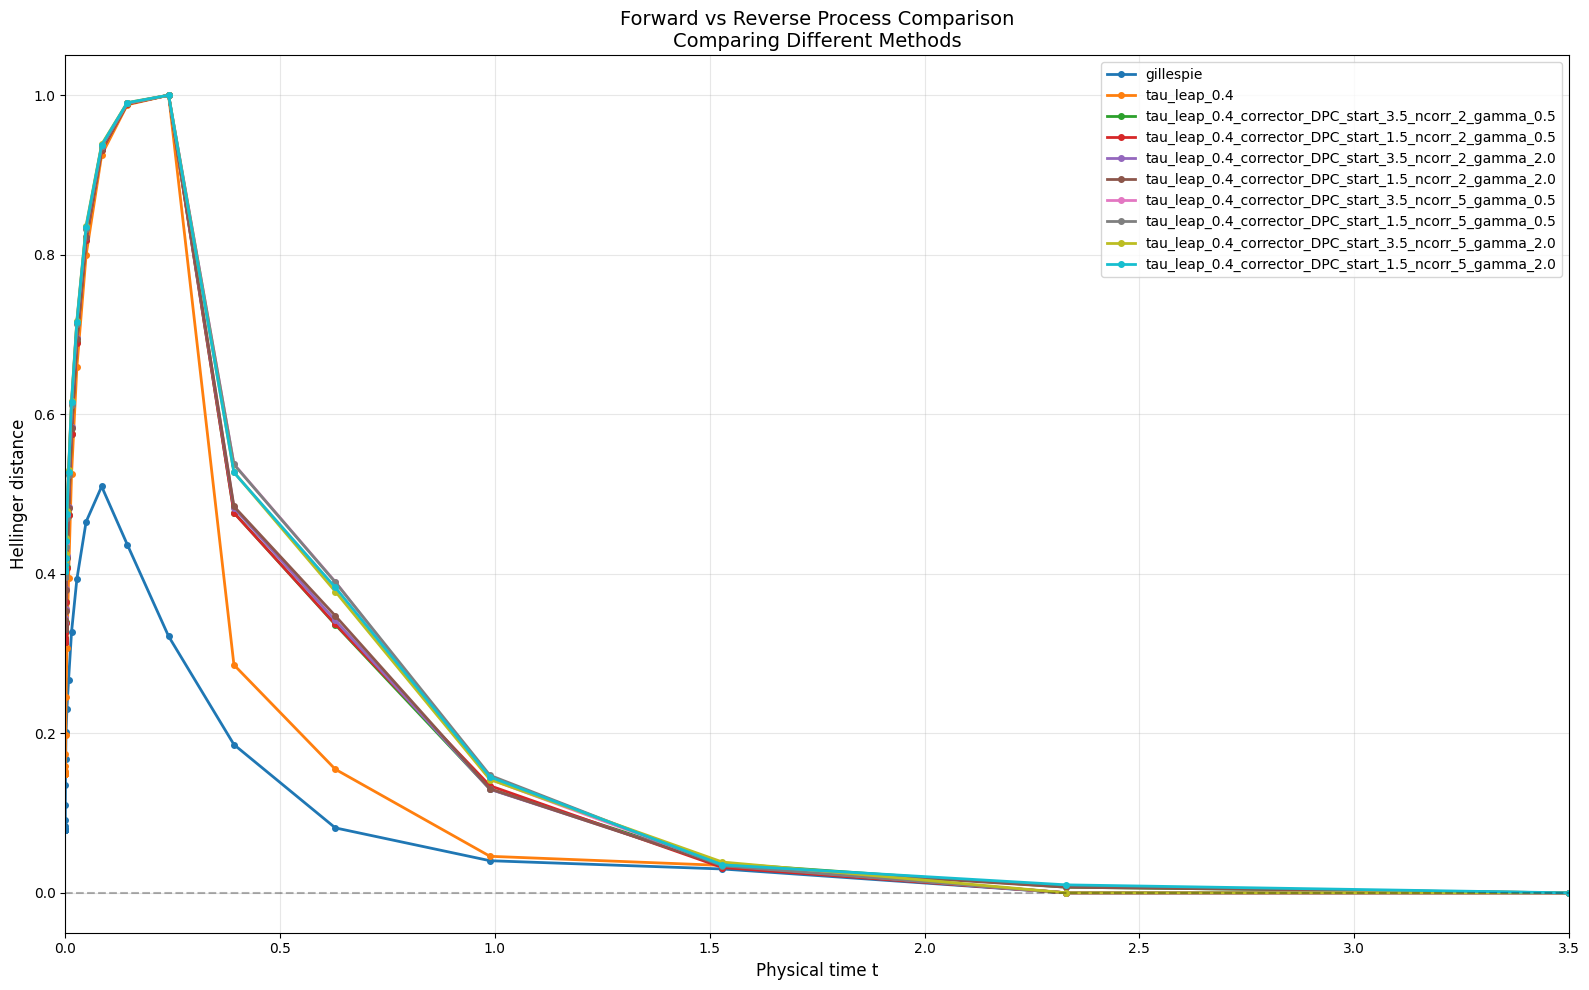


Checkpoint at t=0: 0.000000

Rank   Hellinger    Method
----------------------------------------------------------------------------------------------------
1      0.078632     gillespie [BASELINE]
2      0.149294     tau_leap_0.4 [BASELINE]
3      0.314673     tau_leap_0.4_corrector_DPC_start_1.5_ncorr_2_gamma_0.5 
4      0.315331     tau_leap_0.4_corrector_DPC_start_3.5_ncorr_2_gamma_0.5 
5      0.331176     tau_leap_0.4_corrector_DPC_start_1.5_ncorr_2_gamma_2.0 
6      0.333566     tau_leap_0.4_corrector_DPC_start_3.5_ncorr_2_gamma_2.0 
7      0.396014     tau_leap_0.4_corrector_DPC_start_1.5_ncorr_5_gamma_0.5 
8      0.401612     tau_leap_0.4_corrector_DPC_start_3.5_ncorr_5_gamma_0.5 
9      0.402961     tau_leap_0.4_corrector_DPC_start_1.5_ncorr_5_gamma_2.0 
10     0.407673     tau_leap_0.4_corrector_DPC_start_3.5_ncorr_5_gamma_2.0 

SUMMARY

Baselines:
  gillespie:    0.078632
  tau_leap_0.4: 0.149294

DPC corrector (8 methods):
  Best:   0.314673
  Worst:  0.407673
  Mean:   0.

In [3]:
# ===== Add DPC Corrector Methods =====
print("\nAdding DPC corrector methods...")

dpc_methods = []

for n_corr in [ 2, 5]:
    for gamma in [0.5,  2.0]:
        for start in [3.5,  1.5]:
            dpc_methods.append({
                'type': 'tau_leap',
                'tau': 0.4,
                'corrector': True,
                'corrector_method': 'DPC',
                'corrector_start': start,
                'corrector_hyperparameters': {
                    'n_corr': n_corr,
                    'gamma': gamma
                }
            })

print(f"Total DPC methods to add: {len(dpc_methods)}")
print(f"  n_corr values: [1, 2, 5]")
print(f"  gamma values: [0.5, 1.0, 2.0]")
print(f"  start times: [3.5, 2.5, 1.5, 0.5]")
print(f"  Total: 3 × 3 × 4 = {len(dpc_methods)}")

# Add in batches of 5 with verbose=True to see errors
batch_size = 5
total_batches = (len(dpc_methods) + batch_size - 1) // batch_size
total_added = 0

for batch_idx in range(0, len(dpc_methods), batch_size):
    batch = dpc_methods[batch_idx:batch_idx + batch_size]
    batch_num = batch_idx // batch_size + 1

    print(f"\nBatch {batch_num}/{total_batches}...")

    results = add_methods_to_lightweight_file(
        filename + '.pkl',
        batch,
        verbose=True  # ← Changed to True to see errors
    )

    total_added += len(results['methods_added'])
    print(f"  ✓ Added {len(results['methods_added'])} methods "
          f"({total_added}/{len(dpc_methods)} total)")
    print(f"  Methods added in this batch: {results['methods_added']}")
    print(f"  All methods in file now: {results['existing_methods']}")

# ===== Print Hellinger at t=0 =====
print("\n" + "=" * 70)
print("HELLINGER DISTANCES AT t=0")
print("=" * 70)

data, metadata = load_samples(filename + '.pkl')
methods = list(data['reverse_pmfs'].keys())
times = data['times']
t_zero = times[np.argmin(np.abs(times - 0.0))]

print(f"\nMethods currently in file ({len(methods)}):")
for m in methods:
    print(f"  - {m}")

# Get distances via plot function
all_distances = plot_method_comparison(
    data,
    methods=None,
    filename=f'{filename}_all_methods.png',
    figsize=(16, 10),
    show_annotations=False,
    return_distances=True
)

# Extract at t=0 and sort
results_t0 = []
for method in methods:
    h = all_distances[method][float(t_zero)]
    results_t0.append({'method': method, 'hellinger': h})

results_t0.sort(key=lambda x: x['hellinger'])

print(f"\nCheckpoint at t=0: {t_zero:.6f}")
print(f"\n{'Rank':<6} {'Hellinger':<12} {'Method'}")
print("-" * 100)
for i, r in enumerate(results_t0, 1):
    marker = "[BASELINE]" if r['method'] in ['gillespie', 'tau_leap_0.4'] else ""
    print(f"{i:<6} {r['hellinger']:<12.6f} {r['method']} {marker}")

# Summary
dpc_results = [r for r in results_t0 if 'DPC' in r['method']]

if len(dpc_results) == 0:
    print("\n⚠️  NO DPC METHODS FOUND IN FILE!")
    print("The DPC methods failed to save - check error messages above.")
else:
    baseline_tau = next(r['hellinger'] for r in results_t0 if r['method'] == 'tau_leap_0.4')
    baseline_gil = next(r['hellinger'] for r in results_t0 if r['method'] == 'gillespie')

    print("\n" + "=" * 70)
    print("SUMMARY")
    print("=" * 70)
    print(f"\nBaselines:")
    print(f"  gillespie:    {baseline_gil:.6f}")
    print(f"  tau_leap_0.4: {baseline_tau:.6f}")
    print(f"\nDPC corrector ({len(dpc_results)} methods):")
    print(f"  Best:   {min(r['hellinger'] for r in dpc_results):.6f}")
    print(f"  Worst:  {max(r['hellinger'] for r in dpc_results):.6f}")
    print(f"  Mean:   {np.mean([r['hellinger'] for r in dpc_results]):.6f}")

    best_dpc = dpc_results[0]
    print(f"\nBest DPC configuration:")
    print(f"  Method: {best_dpc['method']}")
    print(f"  Hellinger: {best_dpc['hellinger']:.6f}")
    print(f"  vs tau_leap_0.4: {best_dpc['hellinger'] - baseline_tau:+.6f}")
    print(f"  vs gillespie:    {best_dpc['hellinger'] - baseline_gil:+.6f}")

print("\n✓ Experiment complete!")
print(f"  File: {filename}.pkl")
print(f"  Plot: {filename}_all_methods.png")